# Bank-position point-selection explorer

## Purpose

The WOCU pipeline delivers hundreds of raw bank points per scope region per survey year,
each labelled `OK`, `UNCERTAIN`, or `OUTLIER`. Before those points can enter a model,
they must be reduced to **one number per region per year**: the distance from the centreline
to the river bank.

This notebook makes that reduction step transparent and justifies the choices behind it:

1. **Only OK-status points are used** — outliers and uncertain detections are shown for
   context but excluded from the selection.
2. **The N furthest OK points are selected** — the bank is where the river has eroded
   furthest, not where the average point sits.
3. **Their mean distance is drawn as a parallel offset line** — this single value becomes
   the `distance_to_centerline` feature used by all downstream models.

A second thread explores the **VVR (Vrijruimte voor de Rivier)** boundary:
the designated erosion zone whose outer edge (the *backline*) is used as a reference
distance. An intuitive view is given of how that is decided, and how it relates to the scope region.


---
## Setup


In [1]:
import sys
sys.path.insert(0, '../../')

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import folium
from shapely import offset_curve
from shapely.geometry import LineString, MultiPoint, Point
from shapely.ops import unary_union, transform as shp_transform

from src import paths as PATHS

RAW_GPKG       = PATHS.DATA_DIR / '01_raw/erosion/wocu_output_fase2_20260210.gpkg'
PROCESSED_GPKG = PATHS.DATA_DIR / '02_processed/erosion/wocu_post_processed_fase2_20260223.gpkg'
VVR_GPKG       = PATHS.DATA_DIR / '01_raw/scope/20260205_signaleringslijn.gpkg'

MIN_SHIFT    = 5.0
N_POINTS     = 3
CLUSTERS     = ['rijn', 'ijssel', 'maas', 'neder']
YEAR_COLORS  = ['#4393c3', '#f4a582', '#a50026']
STATUS_ALPHA = {'OK': 0.80, 'UNCERTAIN': 0.40, 'OUTLIER': 0.20}
VVR_COLOR    = '#7b2d8b'


In [2]:
pts    = gpd.read_file(RAW_GPKG, layer='punten_oever')
cl     = gpd.read_file(RAW_GPKG, layer='centrelines')
scope  = gpd.read_file(RAW_GPKG, layer='vlakken_scope')
vvr_ln = gpd.read_file(VVR_GPKG)
vvr_ts = gpd.read_file(PROCESSED_GPKG, layer='vvr_all_results')

if vvr_ln.crs.to_epsg() != 28992:
    vvr_ln = vvr_ln.to_crs(28992)

cl_lookup    = cl.set_index('position_id')['geometry'].to_dict()
scope_lookup = scope.set_index('position_id')['geometry'].to_dict()

print(f'Bank points     : {len(pts):,}')
print(f'Centrelines     : {len(cl):,}')
print(f'Scope regions   : {len(scope):,}')
print(f'VVR lines       : {len(vvr_ln):,}  CRS: {vvr_ln.crs}')
print(f'VVR time-series : {len(vvr_ts):,} rows  |  {vvr_ts["position_id"].nunique()} regions')
print(f'Bank point years: {sorted(pts["dtm_date"].unique())}')


Bank points     : 4,844,655
Centrelines     : 12,130
Scope regions   : 12,130
VVR lines       : 286  CRS: EPSG:28992
VVR time-series : 4,018 rows  |  1361 regions
Bank point years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)]


/Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in '20260205_signaleringslijn.gpkg': 'Vlak_vrije_ruimte_natuurvriendelijke_oever_pl' (default), 'Vlak_vrije_ruimte_nevegeulen_pl', 'Eigendom_Staat_ln', 'Vlak_vrije_ruimte_nevegeulen_ln', 'Vlak_vrije_ruimte_natuurvriendelijke_oever_ln', 'Eigendom_Staat_pl'. Specify layer parameter to avoid this warning.
  result = read_func(


In [3]:
# ── CRS ──────────────────────────────────────────────────────────────────────
_to_wgs84 = pyproj.Transformer.from_crs('EPSG:28992', 'EPSG:4326', always_xy=True).transform

def rd_to_wgs84(geom):
    return shp_transform(_to_wgs84, geom)


# ── Geometry ──────────────────────────────────────────────────────────────────
def offset_toward_points(centreline, dist, bank_pts_geom):
    """Offset centreline by dist toward the side where the bank points lie."""
    centroid = MultiPoint(list(bank_pts_geom)).centroid
    left  = offset_curve(centreline,  dist)
    right = offset_curve(centreline, -dist)
    if left  is None or left.is_empty:  return right
    if right is None or right.is_empty: return left
    mid_l = left.interpolate(0.5, normalized=True)
    mid_r = right.interpolate(0.5, normalized=True)
    return left if mid_l.distance(centroid) < mid_r.distance(centroid) else right


def _sorted_crossings(ray, geom):
    """Point intersections of ray with geom, sorted nearest to furthest from ray origin."""
    inter = ray.intersection(geom)
    if inter.is_empty:
        return []
    origin = Point(ray.coords[0])
    if inter.geom_type == 'Point':               pts_ = [inter]
    elif inter.geom_type == 'MultiPoint':        pts_ = list(inter.geoms)
    elif inter.geom_type == 'GeometryCollection': pts_ = [g for g in inter.geoms if g.geom_type == 'Point']
    else: pts_ = [Point(c) for c in inter.coords] if hasattr(inter, 'coords') else []
    return sorted(pts_, key=lambda p: origin.distance(p))


def vvr_backline_distance(cline, vvr_union):
    """Return (distance_m, backline_point): furthest perp. crossing of CL midpoint with VVR."""
    if vvr_union is None or vvr_union.is_empty:
        return None, None
    RAY_LEN   = 5000
    mid_param = cline.length / 2
    mid_pt    = cline.interpolate(mid_param)
    eps       = min(1.0, cline.length * 0.01)
    pb = cline.interpolate(max(0.0, mid_param - eps))
    pa = cline.interpolate(min(cline.length, mid_param + eps))
    dx, dy = pa.x - pb.x, pa.y - pb.y
    dn = np.hypot(dx, dy)
    px, py = -dy / dn, dx / dn
    make_ray = lambda ddx, ddy: LineString(
        [(mid_pt.x, mid_pt.y), (mid_pt.x + ddx * RAY_LEN, mid_pt.y + ddy * RAY_LEN)]
    )
    cl_ = _sorted_crossings(make_ray( px,  py), vvr_union)
    cr_ = _sorted_crossings(make_ray(-px, -py), vvr_union)
    crossings = cl_ if len(cl_) >= len(cr_) else cr_
    if not crossings:
        return None, None
    pt = crossings[-1]
    return cline.distance(pt), pt


def flatten_geom_to_lines(geom):
    """Flatten any geometry to a list of plottable LineString parts."""
    if geom is None or geom.is_empty:              return []
    if geom.geom_type in ('LineString', 'LinearRing'): return [geom]
    if geom.geom_type == 'MultiLineString':        return list(geom.geoms)
    if geom.geom_type == 'Polygon':                return [geom.exterior]
    if geom.geom_type == 'MultiPolygon':           return [p.exterior for p in geom.geoms]
    if geom.geom_type == 'GeometryCollection':     return [p for g in geom.geoms for p in flatten_geom_to_lines(g)]
    return [geom]


def pick_across_clusters(ids, clusters=CLUSTERS, n=4):
    """Pick up to n IDs with one from each river cluster first, then fill remaining slots."""
    selected = []
    for cluster in clusters:
        match = next((lid for lid in ids if cluster in lid and lid not in selected), None)
        if match:
            selected.append(match)
    for lid in ids:
        if lid not in selected:
            selected.append(lid)
        if len(selected) == n:
            break
    return selected


# ── Core matplotlib panel helper ──────────────────────────────────────────────
def draw_region(ax, loc_id, col_idx=0, show_vvr=False, show_t1_to_t2_arrow=False):
    """Draw one region panel: scope boundary, CL, bank points + chosen-N line [+ VVR]."""
    grp   = pts[pts['location_id'] == loc_id].copy()
    dates = sorted(grp['dtm_date'].unique())
    cline = cl_lookup.get(loc_id)
    sgeom = scope_lookup.get(loc_id)

    ax.set_aspect('equal')
    ax.set_title(loc_id, fontsize=8.5, pad=5)
    ax.tick_params(labelsize=6)
    if col_idx == 0:
        ax.set_ylabel('Northing (m RD)', fontsize=8)
    ax.set_xlabel('Easting (m RD)', fontsize=8)

    if sgeom is not None:
        bx, by = sgeom.exterior.xy
        ax.fill(bx, by, fc='#f0f0f0', ec='#aaaaaa', lw=1.2, zorder=1)

    local_vvr = vvr_ln[vvr_ln.intersects(sgeom)] if (show_vvr and sgeom is not None) else vvr_ln.iloc[0:0]
    for _, vrow in local_vvr.iterrows():
        for part in flatten_geom_to_lines(vrow.geometry):
            try:
                vx, vy = part.xy
                ax.plot(vx, vy, color=VVR_COLOR, lw=2.5, zorder=7, solid_capstyle='round')
            except NotImplementedError:
                pass

    if cline is not None:
        xs, ys = cline.xy
        ax.plot(xs, ys, color='black', lw=2.5, zorder=5, solid_capstyle='round')
        ax.text(xs[-1], ys[-1], ' CL', fontsize=7, color='black', va='center', zorder=6)

    offset_lines = []
    for d_idx, date in enumerate(dates):
        color  = YEAR_COLORS[d_idx]
        yr_grp = grp[grp['dtm_date'] == date]

        for status, sub in yr_grp.groupby('status'):
            ax.scatter(sub.geometry.x, sub.geometry.y,
                       c=color, s=8, alpha=STATUS_ALPHA.get(status, 0.3),
                       linewidths=0, zorder=3)

        ok_grp = yr_grp[yr_grp['status'] == 'OK']
        chosen = ok_grp.nlargest(N_POINTS, 'dist')
        if chosen.empty:
            offset_lines.append(None)
            if cline is not None:
                mid_cl = cline.interpolate(0.5, normalized=True)
                ax.text(mid_cl.x, mid_cl.y, f'{date}\nno OK pts',
                        fontsize=5.5, color=color, ha='center', va='bottom', zorder=9,
                        bbox=dict(fc='white', ec=color, alpha=0.7, pad=1, lw=0.8))
            continue
        mean_dist = chosen['dist'].mean()
        n_ok    = len(ok_grp)
        n_total = len(yr_grp)
        ax.scatter(chosen.geometry.x, chosen.geometry.y,
                   c=color, s=110, edgecolors='black', lw=0.8, zorder=8)

        if cline is not None:
            offset_line = offset_toward_points(cline, mean_dist, chosen.geometry)
            if offset_line is not None and not offset_line.is_empty:
                offset_lines.append(offset_line)
                ox, oy = offset_line.xy
                ax.plot(ox, oy, color=color, lw=2.2, ls='--', zorder=6, alpha=0.95)
                mid = offset_line.interpolate(0.5, normalized=True)
                ax.text(mid.x, mid.y, f'{date}\n{mean_dist:.1f} m  ({n_ok}/{n_total} OK)',
                        fontsize=5.5, color=color, ha='center', va='bottom', zorder=9,
                        bbox=dict(fc='white', ec='none', alpha=0.65, pad=1))
            else:
                offset_lines.append(None)
        else:
            offset_lines.append(None)

    ARROW_OFFSET = 10.0  # metres perpendicular to arrow
    if show_t1_to_t2_arrow and len(offset_lines) >= 2 and offset_lines[0] is not None and offset_lines[1] is not None:
        p1 = offset_lines[0].interpolate(0.5, normalized=True)
        p2 = offset_lines[1].interpolate(0.5, normalized=True)
        dx, dy = p2.x - p1.x, p2.y - p1.y
        dn = np.hypot(dx, dy)
        if dn > 1e-6:
            ux, uy = -dy / dn, dx / dn  # left perpendicular
            t1a = (p1.x + ARROW_OFFSET * ux, p1.y + ARROW_OFFSET * uy)
            t2a = (p2.x + ARROW_OFFSET * ux, p2.y + ARROW_OFFSET * uy)
        else:
            t1a, t2a = (p1.x, p1.y), (p2.x, p2.y)
        ax.annotate('', xy=t2a, xytext=t1a,
                    arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle=':',
                                   mutation_scale=25, connectionstyle='arc3,rad=0'))
    if show_t1_to_t2_arrow and len(offset_lines) >= 3 and offset_lines[1] is not None and offset_lines[2] is not None:
        p2 = offset_lines[1].interpolate(0.5, normalized=True)
        p3 = offset_lines[2].interpolate(0.5, normalized=True)
        dx, dy = p3.x - p2.x, p3.y - p2.y
        dn = np.hypot(dx, dy)
        if dn > 1e-6:
            ux, uy = dy / dn, -dx / dn  # right perpendicular
            t2b = (p2.x + (ARROW_OFFSET*2) * ux, p2.y + (ARROW_OFFSET*2) * uy)
            t3b = (p3.x + (ARROW_OFFSET*2) * ux, p3.y + (ARROW_OFFSET*2) * uy)
        else:
            t2b, t3b = (p2.x, p2.y), (p3.x, p3.y)
        ax.annotate('', xy=t3b, xytext=t2b,
                    arrowprops=dict(arrowstyle='->', color='#4393c3', lw=2, linestyle=':',
                                   mutation_scale=25, connectionstyle='arc3,rad=0'))

    if show_vvr and cline is not None and not local_vvr.empty:
        vvr_dist, p_vvr = vvr_backline_distance(cline, unary_union(local_vvr.geometry))
        if vvr_dist is not None:
            vvr_ref = offset_toward_points(cline, vvr_dist, gpd.GeoSeries([p_vvr]))
            if vvr_ref is not None and not vvr_ref.is_empty:
                for part in flatten_geom_to_lines(vvr_ref):
                    rx, ry = part.xy
                    ax.plot(rx, ry, color=VVR_COLOR, lw=2.5, ls='-.', zorder=7, alpha=0.95)
                mid_vvr = vvr_ref.interpolate(0.5, normalized=True)
                ax.text(mid_vvr.x, mid_vvr.y, f'VVR backline\n{vvr_dist:.1f} m',
                        fontsize=5.5, color=VVR_COLOR, ha='center', va='top', zorder=9,
                        bbox=dict(fc='white', ec='none', alpha=0.65, pad=1))
            ax.scatter([p_vvr.x], [p_vvr.y], c=VVR_COLOR, s=40, zorder=10, marker='x')

        region_vvr = vvr_ts[vvr_ts['position_id'] == loc_id].sort_values('annum')
        if not region_vvr.empty:
            lines = ['VVR dist to signaleringlijn:']
            for _, r in region_vvr.iterrows():
                lines.append(f"  {int(r['annum'])}: {r['distance_to_signaleringlijn']:.1f} m "
                             f"({r['percentage_consumed']:.1f}% consumed)")
            ax.text(0.02, 0.02, '\n'.join(lines),
                    transform=ax.transAxes, fontsize=6, va='bottom', ha='left', zorder=10,
                    bbox=dict(fc='white', ec=VVR_COLOR, alpha=0.8, pad=3, lw=1))


---
## Region selection

Not all scope regions are useful for exploration: some have only one or two survey
years, or barely any movement between surveys. We restrict to regions that have
**exactly three survey timestamps** and show **at least `MIN_SHIFT` metres of movement
between each consecutive pair** (using all-point distances so the selection is stable
and comparable with earlier notebook runs).

Four representative examples are then picked — one per major river cluster
(Rijn, IJssel, Maas, Neder-Rijn).

A second, stricter selection (`vvr_selected`) additionally requires that a VVR boundary
line geometrically intersects the scope polygon, used for Parts 2–4.


In [4]:
def mean_dist_furthest(group):
    """All-points distance — used for region selection so results match the old notebook."""
    return group.nlargest(N_POINTS, 'dist')['dist'].mean()

def mean_dist_ok_furthest(group):
    """OK-only distance — used for VVR qualifying (stricter)."""
    ok = group[group['status'] == 'OK']
    return ok.nlargest(N_POINTS, 'dist')['dist'].mean() if len(ok) >= N_POINTS else np.nan

# Region selection uses all-points distance so the shown regions are stable
# and comparable with older notebook runs. OK-only filtering happens inside draw_region.
agg = (
    pts.groupby(['location_id', 'dtm_date'])
       .apply(mean_dist_furthest, include_groups=False)
       .reset_index(name='mean_dist')
)

ts_counts = agg.groupby('location_id')['dtm_date'].nunique()
agg = (agg[agg['location_id'].isin(ts_counts[ts_counts == 3].index)]
       .sort_values(['location_id', 'dtm_date']))
agg['rank'] = agg.groupby('location_id').cumcount()

wide = (agg.pivot(index='location_id', columns='rank', values='mean_dist')
           .rename(columns={0: 'd_t1', 1: 'd_t2', 2: 'd_t3'}))
wide['shift_t1t2'] = (wide['d_t2'] - wide['d_t1']).abs()
wide['shift_t2t3'] = (wide['d_t3'] - wide['d_t2']).abs()
qualifying = wide[
    (wide['shift_t1t2'] >= MIN_SHIFT) & (wide['shift_t2t3'] >= MIN_SHIFT)
].sort_values('shift_t1t2', ascending=False)

# Part 1 selection: any qualifying region
selected = pick_across_clusters(qualifying.index.tolist())

# Part 2 selection: qualifying + VVR geometry actually intersects scope polygon
vvr_ids = set(vvr_ts['position_id'].unique())
vvr_qualifying = [
    lid for lid in qualifying.index
    if lid in vvr_ids
    and scope_lookup.get(lid) is not None
    and vvr_ln.intersects(scope_lookup[lid]).any()
]
vvr_selected = pick_across_clusters(vvr_qualifying)

print(f'Regions with 3 timestamps + >=MIN_SHIFT shift each step : {len(qualifying):,}')
print(f'  of which with VVR geometric coverage                  : {len(vvr_qualifying):,}')
print(f'\nPart 1 sample : {selected}')
print(f'Part 2 sample : {vvr_selected}')
print()
print(qualifying.loc[selected].round(2))


Regions with 3 timestamps + >=MIN_SHIFT shift each step : 774
  of which with VVR geometric coverage                  : 69

Part 1 sample : ['rijn_l_5440_5450', 'ijssel1_r_2190_2200', 'maas2_r_2750_2760', 'nederrijn_r_8050_8060']
Part 2 sample : ['rijn_l_9240_9250', 'ijssel1_l_7180_7190', 'maas3_l_17590_17600', 'nederrijn_r_7280_7290']

rank                     d_t1    d_t2    d_t3  shift_t1t2  shift_t2t3
location_id                                                          
rijn_l_5440_5450       327.40  115.42  332.90      211.98      217.49
ijssel1_r_2190_2200    116.50   51.42   57.33       65.08        5.92
maas2_r_2750_2760       71.19  163.99  141.71       92.80       22.28
nederrijn_r_8050_8060   76.58  181.43  171.42      104.85       10.01


---
## Part 1 — Reducing bank points to a single distance per year

Each scope region has tens to hundreds of bank points per survey year. We reduce them
to **one representative distance** using the following rule:

> Take the **N furthest OK-status points** from the centreline and compute their mean
> perpendicular distance. Draw a parallel offset line of the centreline at that distance.

Rationale: the river bank is defined by where erosion has reached furthest, not by the
centroid of all detected points. Outliers and uncertain detections are shown at reduced
opacity for context but are excluded from the selection.

The annotation on each line shows `mean_dist (n_ok/n_total OK)`. If a year has zero
OK points the line is replaced by a `no OK pts` label.


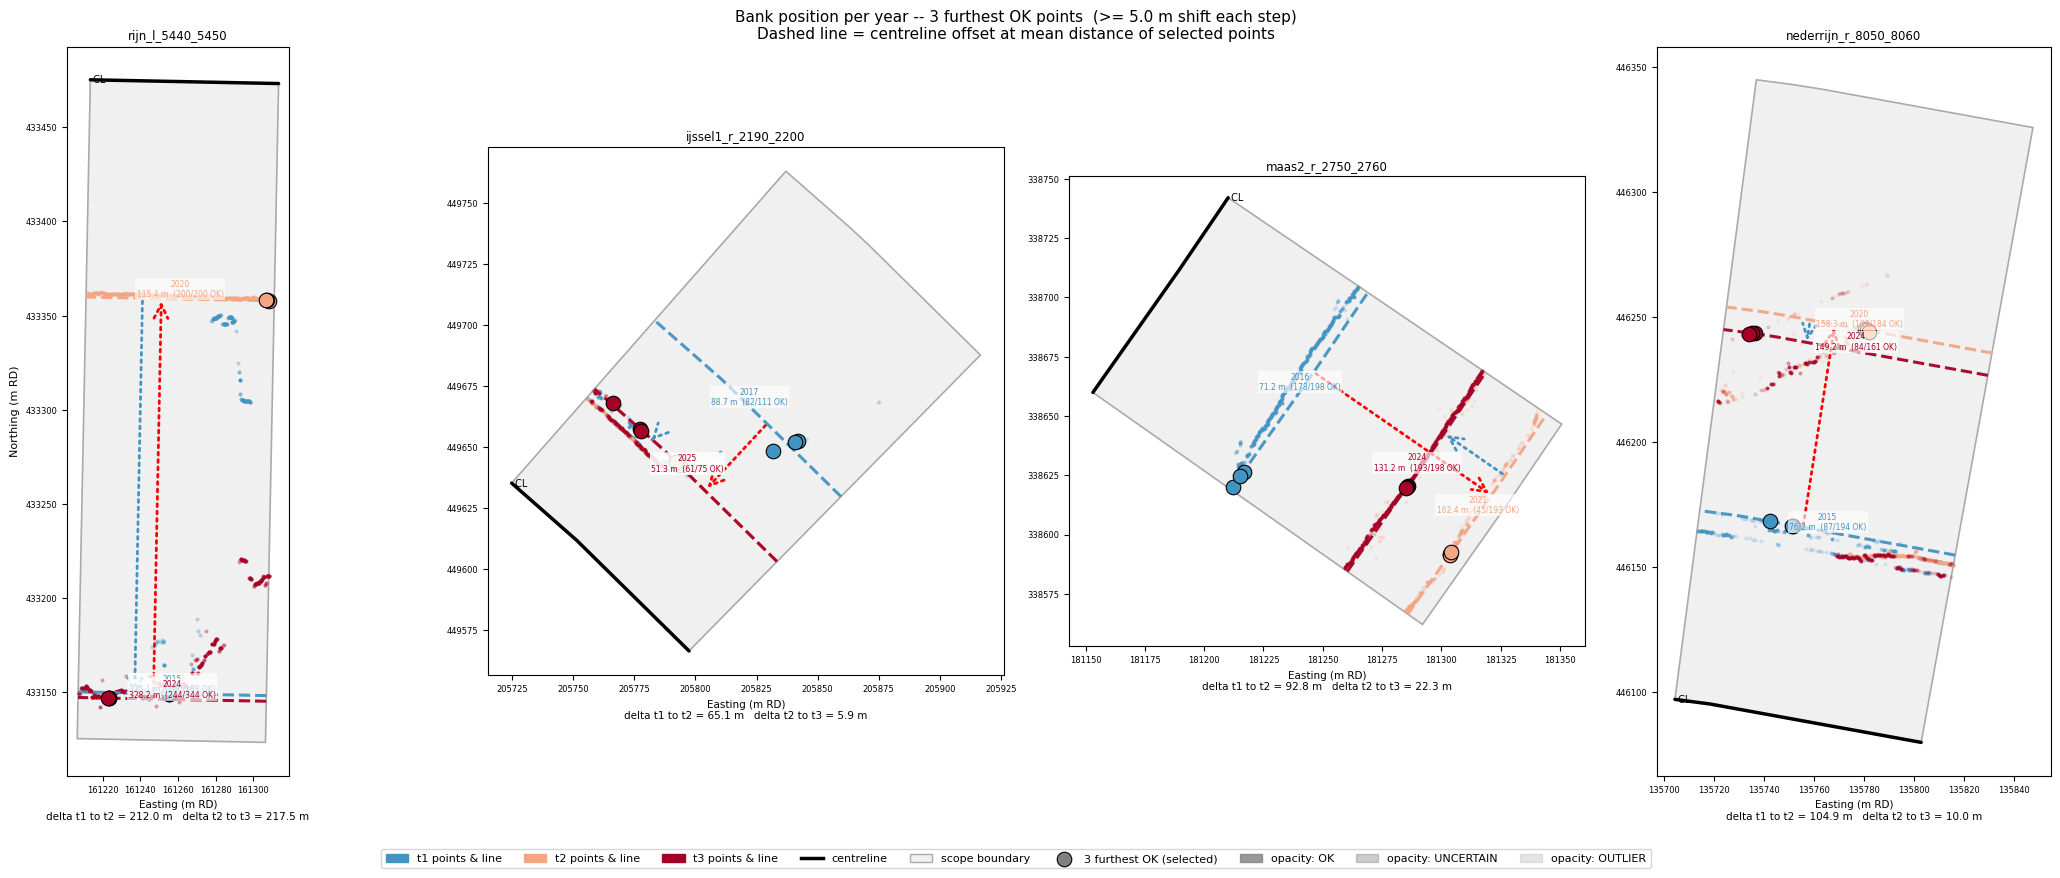

In [5]:
fig, axes = plt.subplots(1, len(selected), figsize=(5.5 * len(selected), 8),
                         constrained_layout=True)

for col, loc_id in enumerate(selected):
    draw_region(axes[col], loc_id, col_idx=col, show_vvr=False, show_t1_to_t2_arrow=True)
    info = qualifying.loc[loc_id]
    axes[col].set_xlabel(
        f'Easting (m RD)\n'
        f'delta t1 to t2 = {info["shift_t1t2"]:.1f} m   delta t2 to t3 = {info["shift_t2t3"]:.1f} m',
        fontsize=7.5
    )

year_patches = [mpatches.Patch(color=YEAR_COLORS[i], label=f't{i+1} points & line') for i in range(3)]
legend_extra = [
    plt.Line2D([0], [0], color='black', lw=2.5, label='centreline'),
    mpatches.Patch(fc='#f0f0f0', ec='#aaaaaa', label='scope boundary'),
    plt.scatter([], [], s=110, c='grey', edgecolors='black', lw=0.8,
                label=f'{N_POINTS} furthest OK (selected)'),
    mpatches.Patch(color='grey', alpha=0.80, label='opacity: OK'),
    mpatches.Patch(color='grey', alpha=0.40, label='opacity: UNCERTAIN'),
    mpatches.Patch(color='grey', alpha=0.20, label='opacity: OUTLIER'),
]
fig.legend(handles=year_patches + legend_extra, loc='lower center', ncol=9, fontsize=8,
           bbox_to_anchor=(0.5, -0.06), frameon=True)
fig.suptitle(
    f'Bank position per year -- {N_POINTS} furthest OK points  (>= {MIN_SHIFT} m shift each step)\n'
    'Dashed line = centreline offset at mean distance of selected points',
    fontsize=11, y=1.02
)
plt.show()


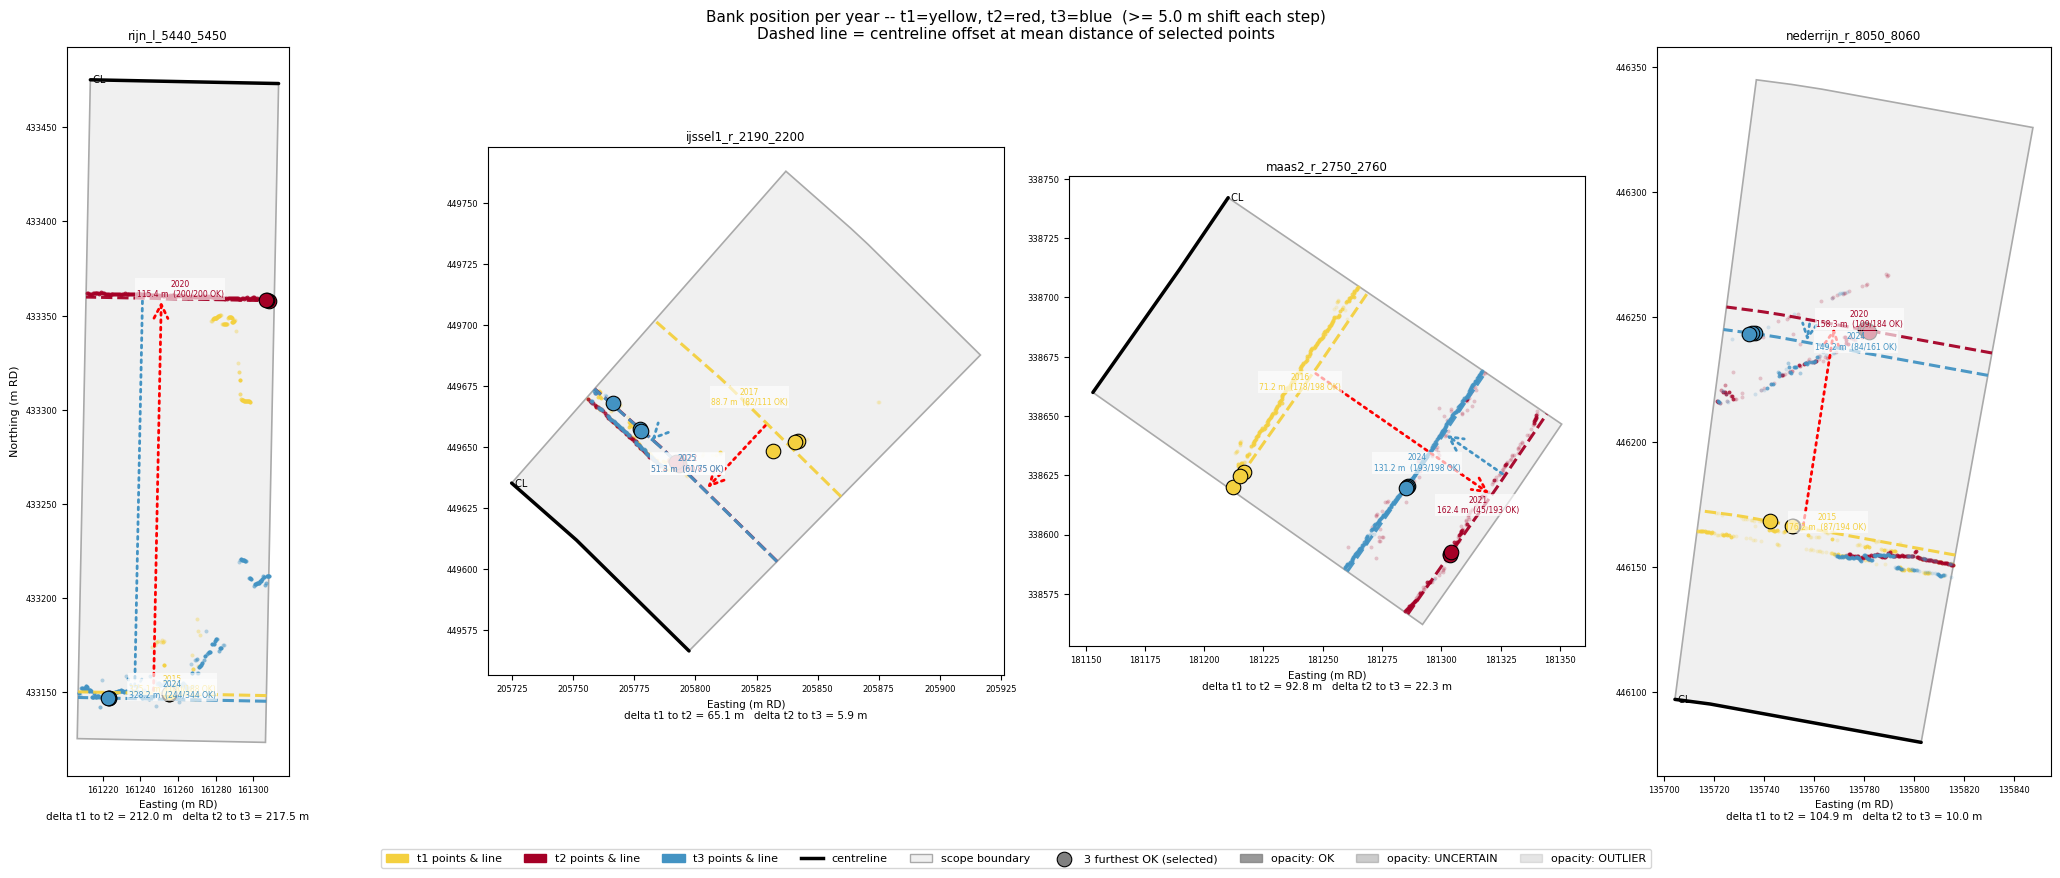

In [6]:
# Same figure with alternate colors: t1=yellowish, t2=red, t3=blue
YEAR_COLORS_ALT = ['#f4d03f', '#a50026', '#4393c3']  # yellowish, red, blue
_orig = YEAR_COLORS
YEAR_COLORS = YEAR_COLORS_ALT

fig, axes = plt.subplots(1, len(selected), figsize=(5.5 * len(selected), 8),
                         constrained_layout=True)

for col, loc_id in enumerate(selected):
    draw_region(axes[col], loc_id, col_idx=col, show_vvr=False, show_t1_to_t2_arrow=True)
    info = qualifying.loc[loc_id]
    axes[col].set_xlabel(
        f'Easting (m RD)\n'
        f'delta t1 to t2 = {info["shift_t1t2"]:.1f} m   delta t2 to t3 = {info["shift_t2t3"]:.1f} m',
        fontsize=7.5
    )

year_patches = [mpatches.Patch(color=YEAR_COLORS[i], label=f't{i+1} points & line') for i in range(3)]
legend_extra = [
    plt.Line2D([0], [0], color='black', lw=2.5, label='centreline'),
    mpatches.Patch(fc='#f0f0f0', ec='#aaaaaa', label='scope boundary'),
    plt.scatter([], [], s=110, c='grey', edgecolors='black', lw=0.8,
                label=f'{N_POINTS} furthest OK (selected)'),
    mpatches.Patch(color='grey', alpha=0.80, label='opacity: OK'),
    mpatches.Patch(color='grey', alpha=0.40, label='opacity: UNCERTAIN'),
    mpatches.Patch(color='grey', alpha=0.20, label='opacity: OUTLIER'),
]
fig.legend(handles=year_patches + legend_extra, loc='lower center', ncol=9, fontsize=8,
           bbox_to_anchor=(0.5, -0.06), frameon=True)
fig.suptitle(
    f'Bank position per year -- t1=yellow, t2=red, t3=blue  (>= {MIN_SHIFT} m shift each step)\n'
    'Dashed line = centreline offset at mean distance of selected points',
    fontsize=11, y=1.02
)
plt.show()

YEAR_COLORS = _orig  # restore

In [7]:
rows = []
for loc_id in selected:
    grp = pts[pts['location_id'] == loc_id]
    for d_idx, date in enumerate(sorted(grp['dtm_date'].unique())):
        yr_grp = grp[grp['dtm_date'] == date]
        chosen = yr_grp[yr_grp['status'] == 'OK'].nlargest(N_POINTS, 'dist')
        rows.append({
            'region'     : loc_id,
            'timestamp'  : f't{d_idx+1} ({date})',
            'mean_dist_m': round(chosen['dist'].mean(), 2),
            'n_ok'       : int((yr_grp['status'] == 'OK').sum()),
            'n_total'    : len(yr_grp),
        })

df = pd.DataFrame(rows)
pivot = df.pivot_table(index='region', columns='timestamp', values='mean_dist_m', aggfunc='first')
t_cols = sorted(pivot.columns)
pivot['delta t1 to t2 (m)'] = (pivot[t_cols[1]] - pivot[t_cols[0]]).round(2)
pivot['delta t2 to t3 (m)'] = (pivot[t_cols[2]] - pivot[t_cols[1]]).round(2)
print('Mean dist (m) of N furthest OK points -- selected regions:')
display(pivot.round(2))

ok_piv  = df.pivot_table(index='region', columns='timestamp', values='n_ok',    aggfunc='first')
tot_piv = df.pivot_table(index='region', columns='timestamp', values='n_total', aggfunc='first')
print('\nOK / total bank points per region-year:')
display(ok_piv.astype(str) + ' / ' + tot_piv.astype(str))


Mean dist (m) of N furthest OK points -- selected regions:


timestamp,t1 (2015),t1 (2016),t1 (2017),t2 (2020),t2 (2021),t2 (2022),t3 (2024),t3 (2025),delta t1 to t2 (m),delta t2 to t3 (m)
region,,,,,,,,,,
ijssel1_r_2190_2200,NaN,NaN,88.67,NaN,NaN,51.42,NaN,51.33,NaN,NaN
maas2_r_2750_2760,NaN,71.19,NaN,NaN,162.41,NaN,131.19,NaN,NaN,NaN
nederrijn_r_8050_8060,76.16,NaN,NaN,158.32,NaN,NaN,149.23,NaN,NaN,NaN
rijn_l_5440_5450,325.15,NaN,NaN,115.42,NaN,NaN,328.15,NaN,NaN,NaN



OK / total bank points per region-year:


timestamp,t1 (2015),t1 (2016),t1 (2017),t2 (2020),t2 (2021),t2 (2022),t3 (2024),t3 (2025)
region,,,,,,,,
ijssel1_r_2190_2200,nan / nan,nan / nan,82.0 / 111.0,nan / nan,nan / nan,80.0 / 85.0,nan / nan,61.0 / 75.0
maas2_r_2750_2760,nan / nan,178.0 / 198.0,nan / nan,nan / nan,45.0 / 193.0,nan / nan,193.0 / 198.0,nan / nan
nederrijn_r_8050_8060,87.0 / 194.0,nan / nan,nan / nan,109.0 / 184.0,nan / nan,nan / nan,84.0 / 161.0,nan / nan
rijn_l_5440_5450,100.0 / 188.0,nan / nan,nan / nan,200.0 / 200.0,nan / nan,nan / nan,244.0 / 344.0,nan / nan


---
## Part 2 — VVR backline: how we measure remaining erosion space

The VVR (*Vrijruimte voor de Rivier*, freedom of movement for the river) is the zone
within which the river bank is permitted to erode. Its outer boundary is the
**signaleringlijn** — the threshold beyond which erosion is a concern.

To measure how much of that space remains, we need a single reference distance from
the centreline to the back of the VVR band. We derive this by:

1. Shooting a perpendicular ray from the midpoint of the centreline outward
2. Collecting all intersections with the VVR geometry
3. Taking the **furthest crossing** — the outer edge of the band

The plot below shows the bank-position lines (Part 1) overlaid with the VVR boundary
(solid purple) and the derived backline reference (dash-dot purple).


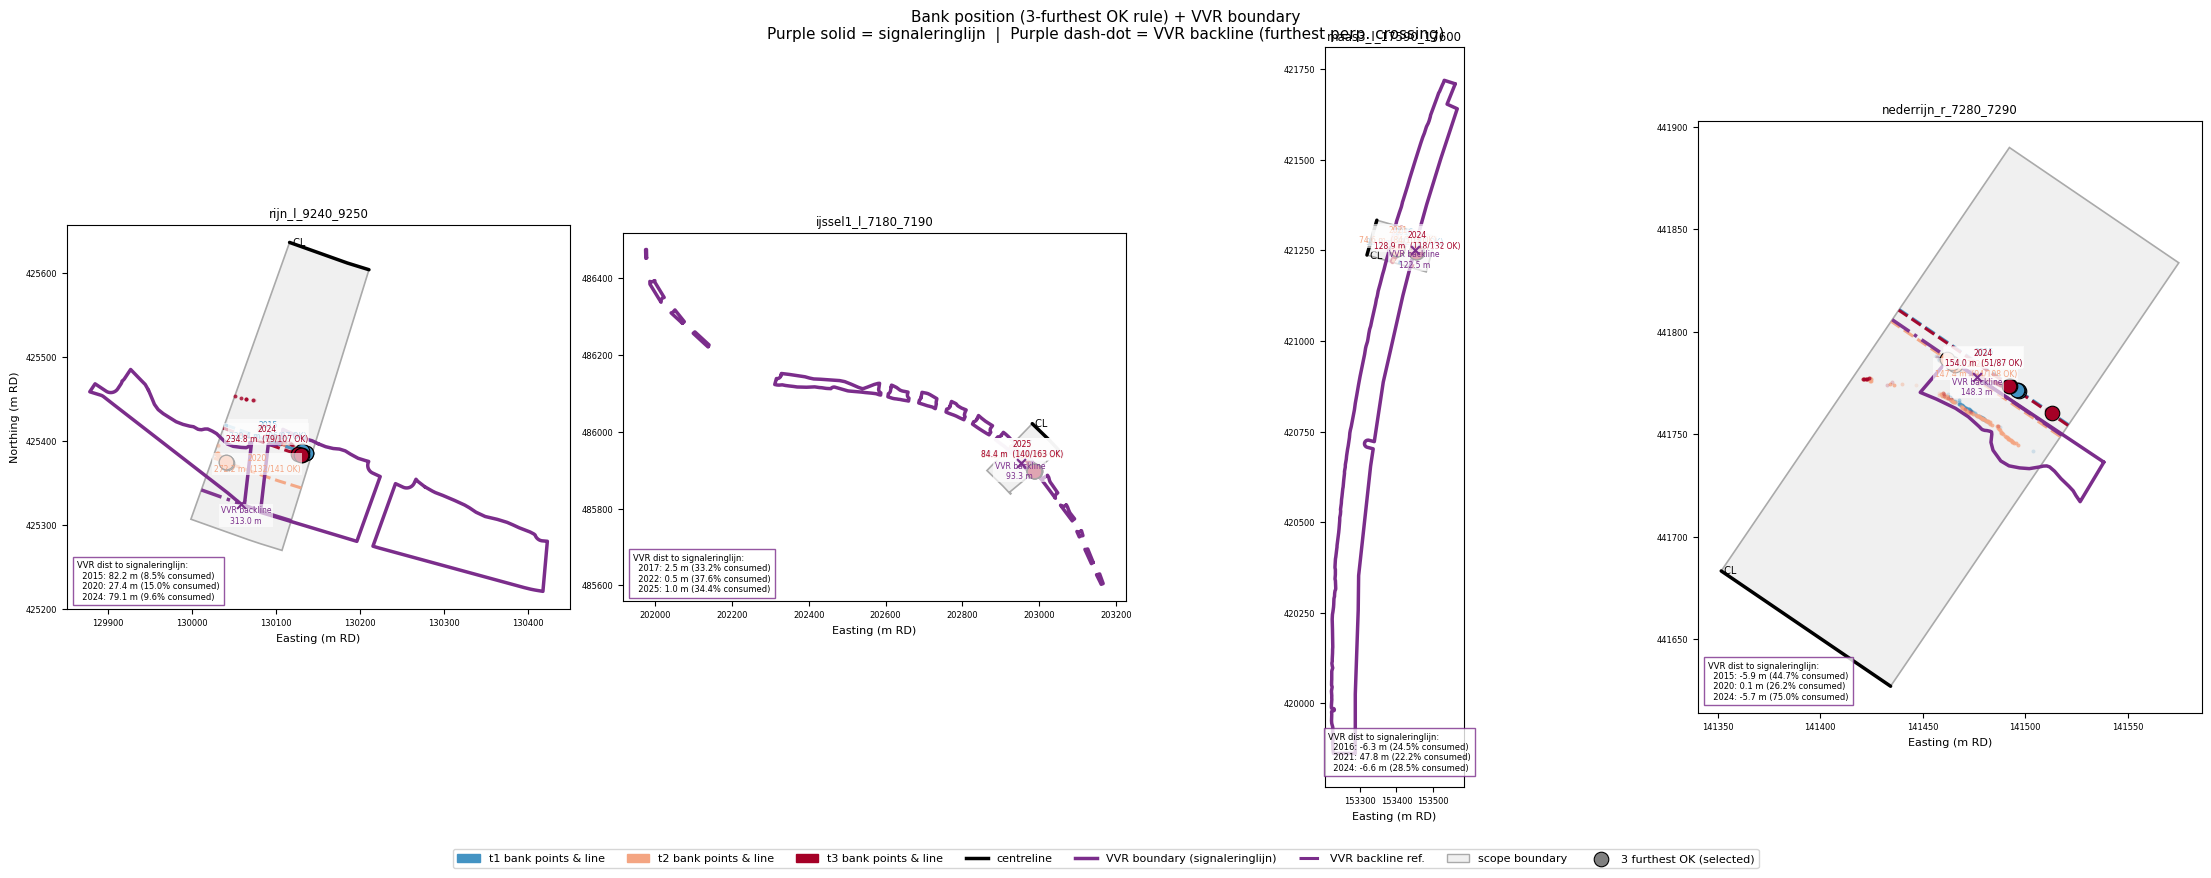

In [8]:
fig, axes = plt.subplots(1, len(vvr_selected), figsize=(5.5 * len(vvr_selected), 8),
                         constrained_layout=True)

for col, loc_id in enumerate(vvr_selected):
    draw_region(axes[col], loc_id, col_idx=col, show_vvr=True)

year_patches = [mpatches.Patch(color=YEAR_COLORS[i], label=f't{i+1} bank points & line') for i in range(3)]
legend_extra = [
    plt.Line2D([0], [0], color='black',   lw=2.5,          label='centreline'),
    plt.Line2D([0], [0], color=VVR_COLOR, lw=2.5,          label='VVR boundary (signaleringlijn)'),
    plt.Line2D([0], [0], color=VVR_COLOR, lw=2.2, ls='-.',  label='VVR backline ref.'),
    mpatches.Patch(fc='#f0f0f0', ec='#aaaaaa',             label='scope boundary'),
    plt.scatter([], [], s=110, c='grey', edgecolors='black', lw=0.8,
                label=f'{N_POINTS} furthest OK (selected)'),
]
fig.legend(handles=year_patches + legend_extra, loc='lower center', ncol=9, fontsize=8,
           bbox_to_anchor=(0.5, -0.06), frameon=True)
fig.suptitle(
    f'Bank position ({N_POINTS}-furthest OK rule) + VVR boundary\n'
    'Purple solid = signaleringlijn  |  Purple dash-dot = VVR backline (furthest perp. crossing)',
    fontsize=11, y=1.02
)
plt.show()


In [9]:
# OK-point counts for the plotted regions (vvr_selected)
# Shows how many bank points per year were OK vs total, for every displayed region.
rows = []
for loc_id in vvr_selected:
    grp = pts[pts['location_id'] == loc_id]
    for d_idx, date in enumerate(sorted(grp['dtm_date'].unique())):
        yr_grp = grp[grp['dtm_date'] == date]
        counts = yr_grp['status'].value_counts()
        rows.append({
            'region'  : loc_id,
            'year'    : f't{d_idx+1} ({date})',
            'OK'      : counts.get('OK', 0),
            'UNCERTAIN': counts.get('UNCERTAIN', 0),
            'OUTLIER' : counts.get('OUTLIER', 0),
            'total'   : len(yr_grp),
        })

ok_df = pd.DataFrame(rows)
ok_df['OK / total'] = ok_df['OK'].astype(str) + ' / ' + ok_df['total'].astype(str)
ok_df['OK %'] = (ok_df['OK'] / ok_df['total'] * 100).round(1)

pivot = ok_df.pivot_table(
    index='region', columns='year',
    values=['OK / total', 'OK %'],
    aggfunc='first'
)
print('Bank point status counts — VVR-selected regions:')
display(pivot)


Bank point status counts — VVR-selected regions:


OK %                                          \
year                  t1 (2015) t1 (2016) t1 (2017) t2 (2020) t2 (2021)   
region                                                                    
ijssel1_l_7180_7190         NaN       NaN      93.3       NaN       NaN   
maas3_l_17590_17600         NaN      69.2       NaN       NaN      81.6   
nederrijn_r_7280_7290      64.4       NaN       NaN      87.0       NaN   
rijn_l_9240_9250           99.0       NaN       NaN      93.6       NaN   

                                                    OK / total            \
year                  t2 (2022) t3 (2024) t3 (2025)  t1 (2015) t1 (2016)   
region                                                                     
ijssel1_l_7180_7190        93.9       NaN      85.9        NaN       NaN   
maas3_l_17590_17600         NaN      89.4       NaN        NaN  92 / 133   
nederrijn_r_7280_7290       NaN      58.6       NaN    58 / 90       NaN   
rijn_l_9240_9250            NaN      73.8       NaN    96 / 97       NaN   

                                                                             \
year                   t1 (2017)  t2 (2020) t2 (2021)  t2 (2022)  t3 (2024)   
region                                                                        
ijssel1_l_7180_7190    304 / 326        NaN       NaN  459 / 489        NaN   
maas3_l_17590_17600          NaN        NaN  84 / 103        NaN  118 / 132   
nederrijn_r_7280_7290        NaN   94 / 108       NaN        NaN    51 / 87   
rijn_l_9240_9250             NaN  132 / 141       NaN        NaN   79 / 107   

                                  
year                   t3 (2025)  
region                            
ijssel1_l_7180_7190    140 / 163  
maas3_l_17590_17600          NaN  
nederrijn_r_7280_7290        NaN  
rijn_l_9240_9250             NaN

---
## Part 3 — Interactive map exploration

One Folium map per selected VVR region. Layers (toggle in the layer control):
- Scope boundary and centreline
- Bank points per year — colour by year, opacity by status
- Bank-position offset line per year (OK-only, N furthest)
- VVR boundary lines (signaleringlijn) in purple
- VVR backline reference (furthest perpendicular crossing) as a dashed purple line
- Inset box: `distance_to_signaleringlijn` and % consumed per survey year


In [ ]:
from shapely.geometry import mapping

def make_map_for_region(loc_id):
    """Interactive Folium map: bank points (OK only), centreline, VVR + bank positions.
    Bank position uses only OK points. Distances = bank position to VVR backline reference."""
    grp       = pts[pts['location_id'] == loc_id].copy()
    dates     = sorted(grp['dtm_date'].unique())
    cline     = cl_lookup.get(loc_id)
    sgeom     = scope_lookup.get(loc_id)
    local_vvr = vvr_ln[vvr_ln.intersects(sgeom)] if sgeom is not None else vvr_ln.iloc[0:0]

    centre_wgs = rd_to_wgs84(sgeom.centroid if sgeom else grp.geometry.union_all().centroid)
    m = folium.Map(location=[centre_wgs.y, centre_wgs.x], zoom_start=16, tiles='OpenStreetMap')

    if sgeom is not None:
        folium.GeoJson(mapping(rd_to_wgs84(sgeom)), name='Scope boundary',
                       style_function=lambda _: {'color': '#888888', 'weight': 2,
                                                 'fillColor': '#cccccc', 'fillOpacity': 0.15}
                       ).add_to(m)

    vvr_fg = folium.FeatureGroup(name='VVR boundary (signaleringlijn)')
    for _, vrow in local_vvr.iterrows():
        if vrow.geometry and not vrow.geometry.is_empty:
            folium.GeoJson(mapping(rd_to_wgs84(vrow.geometry)),
                           style_function=lambda _: {'color': VVR_COLOR, 'weight': 3.5}
                           ).add_to(vvr_fg)
    vvr_fg.add_to(m)

    if cline is not None:
        folium.GeoJson(mapping(rd_to_wgs84(cline)), name='Centreline',
                       style_function=lambda _: {'color': 'black', 'weight': 2.5}).add_to(m)

    # Compute VVR backline reference early (needed for per-year distances)
    vvr_ref = None
    if cline is not None and not local_vvr.empty:
        vvr_dist, p_vvr = vvr_backline_distance(cline, unary_union(local_vvr.geometry))
        if vvr_dist is not None and p_vvr is not None:
            vvr_ref = offset_toward_points(cline, vvr_dist, gpd.GeoSeries([p_vvr]))
            if vvr_ref is not None and not vvr_ref.is_empty:
                p_vvr_wgs = rd_to_wgs84(p_vvr)
                vvr_ref_fg = folium.FeatureGroup(name='VVR backline reference')
                folium.GeoJson(mapping(rd_to_wgs84(vvr_ref)),
                               style_function=lambda _: {'color': VVR_COLOR, 'weight': 3, 'dashArray': '10 4'},
                               tooltip=f'VVR backline distance = {vvr_dist:.1f} m').add_to(vvr_ref_fg)
                folium.CircleMarker([p_vvr_wgs.y, p_vvr_wgs.x], radius=5, color=VVR_COLOR,
                                    fill=True, fill_color=VVR_COLOR, fill_opacity=1.0, weight=1.5,
                                    tooltip=f'VVR backline  dist = {vvr_dist:.1f} m from CL'
                                    ).add_to(vvr_ref_fg)
                vvr_ref_fg.add_to(m)

    bank_to_vvr_distances = []
    for d_idx, date in enumerate(dates):
        color  = YEAR_COLORS[d_idx]
        yr_grp = grp[grp['dtm_date'] == date]
        label  = f't{d_idx+1} ({date})'

        # Only OK points for bank position
        ok_grp = yr_grp[yr_grp['status'] == 'OK']
        chosen = ok_grp.nlargest(N_POINTS, 'dist')
        mean_dist = chosen['dist'].mean() if not chosen.empty else None

        pts_fg = folium.FeatureGroup(name=f'Bank points {label}')
        for _, row in ok_grp.iterrows():
            pt_wgs = rd_to_wgs84(row.geometry)
            folium.CircleMarker([pt_wgs.y, pt_wgs.x], radius=3, color=color,
                                fill=True, fill_color=color, fill_opacity=0.85, weight=0,
                                tooltip=f"OK  dist={row['dist']:.1f} m  {date}"
                                ).add_to(pts_fg)
        pts_fg.add_to(m)

        if cline is not None and mean_dist is not None and not chosen.empty:
            offset_line = offset_toward_points(cline, mean_dist, chosen.geometry)
            if offset_line is not None and not offset_line.is_empty:
                dist_to_vvr = offset_line.distance(vvr_ref) if vvr_ref is not None else None
                if dist_to_vvr is not None:
                    bank_to_vvr_distances.append((date, dist_to_vvr))
                line_fg = folium.FeatureGroup(name=f'Bank position {label}')
                folium.GeoJson(mapping(rd_to_wgs84(offset_line)),
                               style_function=lambda _, c=color: {'color': c, 'weight': 3, 'dashArray': '8 5'},
                               tooltip=f'{label}  mean dist = {mean_dist:.1f} m').add_to(line_fg)
                for _, r in chosen.iterrows():
                    pt_wgs = rd_to_wgs84(r.geometry)
                    folium.CircleMarker([pt_wgs.y, pt_wgs.x], radius=6, color='black',
                                        fill=True, fill_color=color, fill_opacity=1.0, weight=1.5,
                                        tooltip=f'SELECTED  dist={r["dist"]:.1f} m  OK'
                                        ).add_to(line_fg)
                line_fg.add_to(m)

    if bank_to_vvr_distances:
        html = '<b>Bank position → VVR backline (m)</b><br>' + ''.join(
            f"{int(d)}: <b>{dist:.1f} m</b><br>" for d, dist in bank_to_vvr_distances
        )
        folium.Marker([centre_wgs.y, centre_wgs.x], icon=folium.DivIcon(
            html=f'<div style="background:white;border:2px solid {VVR_COLOR};padding:4px;'
                 f'font-size:11px;border-radius:4px;white-space:nowrap">{html}</div>',
            icon_size=(260, 80), icon_anchor=(0, 0))).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m


for loc_id in vvr_selected:
    print(f'\n{"="*60}\n  {loc_id}\n{"="*60}')
    display(make_map_for_region(loc_id))



  rijn_l_9240_9250



  ijssel1_l_7180_7190



  maas3_l_17590_17600



  nederrijn_r_7280_7290
